<a href="https://colab.research.google.com/github/DalvanKuginharski/IAFIAP/blob/main/DalvanKuginharski_RM568860_fase3_cap10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Modelagem de IA da FarmTech Solutions — Modelos Preditivos

**Nome:** Dalvan Kuginharski  
**RM:** 568860  
**Fase:** 3 | **Capítulo:** 10  

---

## Objetivo

Este notebook realiza:
1. **Análise Exploratória** dos dados de solo e clima;
2. **Análise Descritiva** com pelo menos cinco gráficos comentados;
3. **Perfil Ideal** de solo/clima por cultura, comparando três culturas selecionadas;
4. **Modelos Preditivos** — cinco algoritmos distintos avaliados com métricas pertinentes.

> **Dataset:** `produtos_agricolas.csv` — 2 200 registros, 22 culturas balanceadas (100 por classe).  
> **Variáveis:** N, P, K (nutrientes do solo), temperatura, umidade, pH, precipitação, rótulo de cultura.


## 0. Importações e Configurações

In [5]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score, ConfusionMatrixDisplay)

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

# Estilo visual
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 110, 'figure.figsize': (10, 5)})

print("Bibliotecas carregadas com sucesso ✓")


Bibliotecas carregadas com sucesso ✓


## 1. Carregamento e Inspeção Inicial dos Dados

In [6]:
df = pd.read_csv('produtos_agricolas.csv')

print(f"Dimensões: {df.shape[0]} linhas × {df.shape[1]} colunas")
print()
df.head(10)


Dimensões: 2200 linhas × 8 colunas



,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
5,69,37,42,23.058049,83.370118,7.073454,251.055000,rice
6,69,55,38,22.708838,82.639414,5.700806,271.324860,rice
7,94,53,40,20.277744,82.894086,5.718627,241.974195,rice
8,89,54,38,24.515881,83.535216,6.685346,230.446236,rice
9,68,58,38,23.223974,83.033227,6.336254,221.209196,rice


In [7]:
print("Tipos de dados:")
print(df.dtypes)
print()
print("Valores nulos por coluna:")
print(df.isnull().sum())


Tipos de dados:
N                int64
P                int64
K                int64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
label           object
dtype: object

Valores nulos por coluna:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64


In [8]:
print("Distribuição das culturas (label):")
print(df['label'].value_counts())


Distribuição das culturas (label):
label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64


### Observações iniciais

- O dataset possui **2 200 registros** completamente balanceados: exatamente **100 amostras por cultura** (22 culturas).  
- **Sem valores nulos** em nenhuma coluna — não há necessidade de imputação.  
- As variáveis numéricas variam bastante em escala (N: 0–140; rainfall: 20–299), o que motivará a normalização antes de modelos baseados em distância.  
- A variável alvo `label` é categórica com 22 classes.


## 2. Análise Exploratória dos Dados (EDA)

In [9]:
desc = df.describe().T
desc['cv'] = desc['std'] / desc['mean']   # coeficiente de variação
desc.round(3)


,count,mean,std,min,25%,50%,75%,max,cv
N,2200.0,50.552,36.917,0.000,21.000,37.000,84.250,140.000,0.730
P,2200.0,53.363,32.986,5.000,28.000,51.000,68.000,145.000,0.618
K,2200.0,48.149,50.648,5.000,20.000,32.000,49.000,205.000,1.052
temperature,2200.0,25.616,5.064,8.826,22.769,25.599,28.562,43.675,0.198
humidity,2200.0,71.482,22.264,14.258,60.262,80.473,89.949,99.982,0.311
ph,2200.0,6.469,0.774,3.505,5.972,6.425,6.924,9.935,0.120
rainfall,2200.0,103.464,54.958,20.211,64.552,94.868,124.268,298.560,0.531


### Interpretação das estatísticas descritivas

| Variável | Observação principal |
|---|---|
| **N** (Nitrogênio) | Alta variabilidade (CV ≈ 0,73); vai de 0 a 140. |
| **P** (Fósforo) | Distribuição ampla; mediana (51) ≈ média (53). |
| **K** (Potássio) | Muito assimétrico — P75 = 49, mas máx = 205. |
| **temperature** | Intervalo 9–44 °C; CV baixo (0,20) — relativamente homogênea. |
| **humidity** | Bimodal suspeita — mínimo 14%, máximo 99%. |
| **ph** | Pequena dispersão (0,77); a maioria entre 5,5 e 7,5. |
| **rainfall** | Alta variabilidade; outliers em torno de 298 mm. |


### Gráfico 1 — Distribuição das variáveis numéricas (Histogramas + KDE)

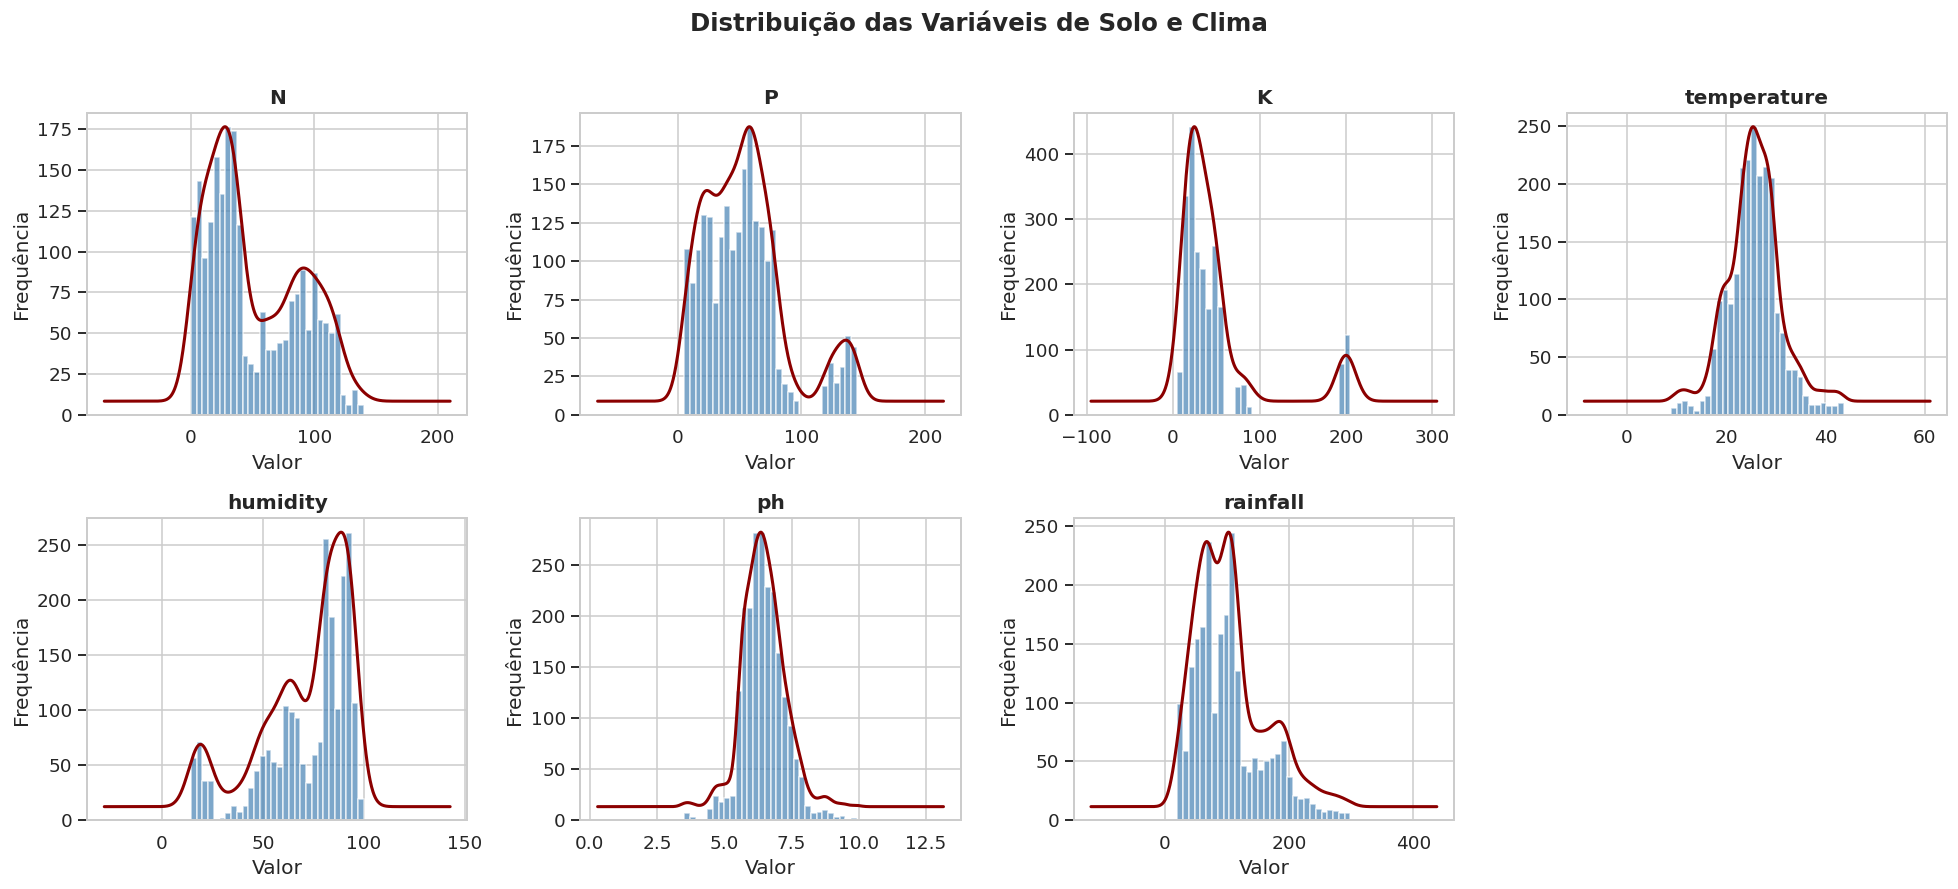

Gráfico 1 salvo.


In [10]:
features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, feat in enumerate(features):
    axes[i].hist(df[feat], bins=30, color='steelblue', alpha=0.7, edgecolor='white')
    ax2 = axes[i].twinx()
    df[feat].plot.kde(ax=ax2, color='darkred', linewidth=2)
    ax2.set_ylabel('')
    ax2.set_yticks([])
    axes[i].set_title(feat, fontweight='bold')
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frequência')

axes[-1].set_visible(False)
fig.suptitle('Distribuição das Variáveis de Solo e Clima', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('g1_distribuicoes.png', bbox_inches='tight')
plt.show()
print("Gráfico 1 salvo.")


**Achado:** Nitrogênio (N), Potássio (K) e precipitação (`rainfall`) apresentam distribuições assimétricas,
sugerindo que diferentes grupos de culturas preferem condições bastante distintas.
O pH tem distribuição próxima à normal, centrada em torno de 6,5 (levemente ácido).


### Gráfico 2 — Matriz de Correlação entre Variáveis Numéricas

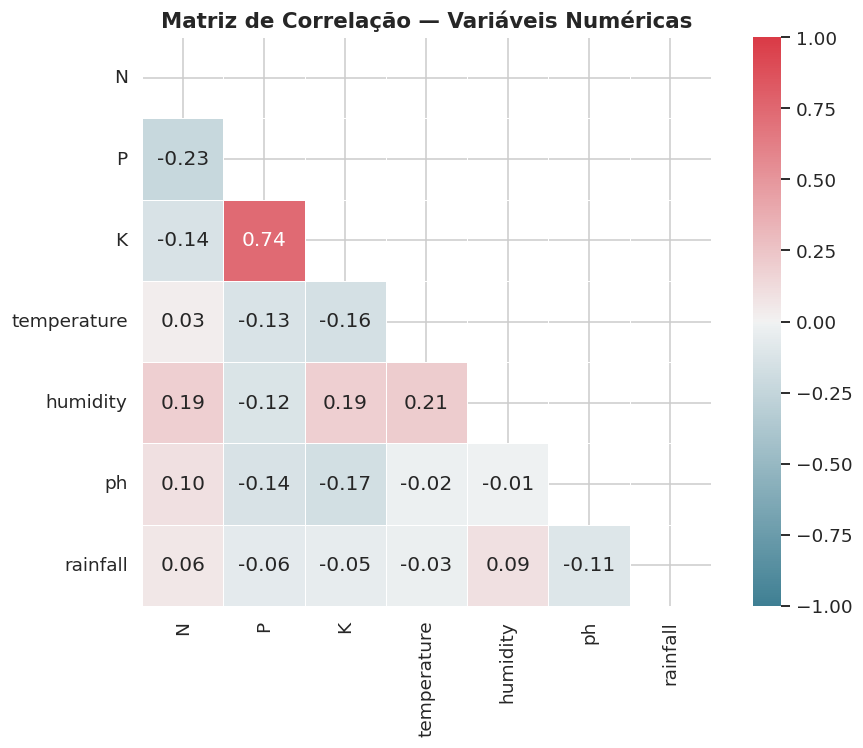

Gráfico 2 salvo.


In [11]:
corr = df[features].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(220, 10, as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=1, vmin=-1, center=0,
            annot=True, fmt='.2f', square=True, linewidths=0.5, ax=ax)
ax.set_title('Matriz de Correlação — Variáveis Numéricas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('g2_correlacao.png', bbox_inches='tight')
plt.show()
print("Gráfico 2 salvo.")


**Achado:** As correlações entre as variáveis são, em sua maioria, fracas ou moderadas.
A maior correlação positiva ocorre entre **N e K** (≈ 0,74), indicando que solos ricos em nitrogênio
tendem a ter mais potássio. Temperatura e umidade apresentam correlação negativa moderada (≈ −0,55),
padrão esperado — regiões mais quentes costumam ser mais secas.


### Gráfico 3 — Boxplot de Nitrogênio (N) e Potássio (K) por Cultura

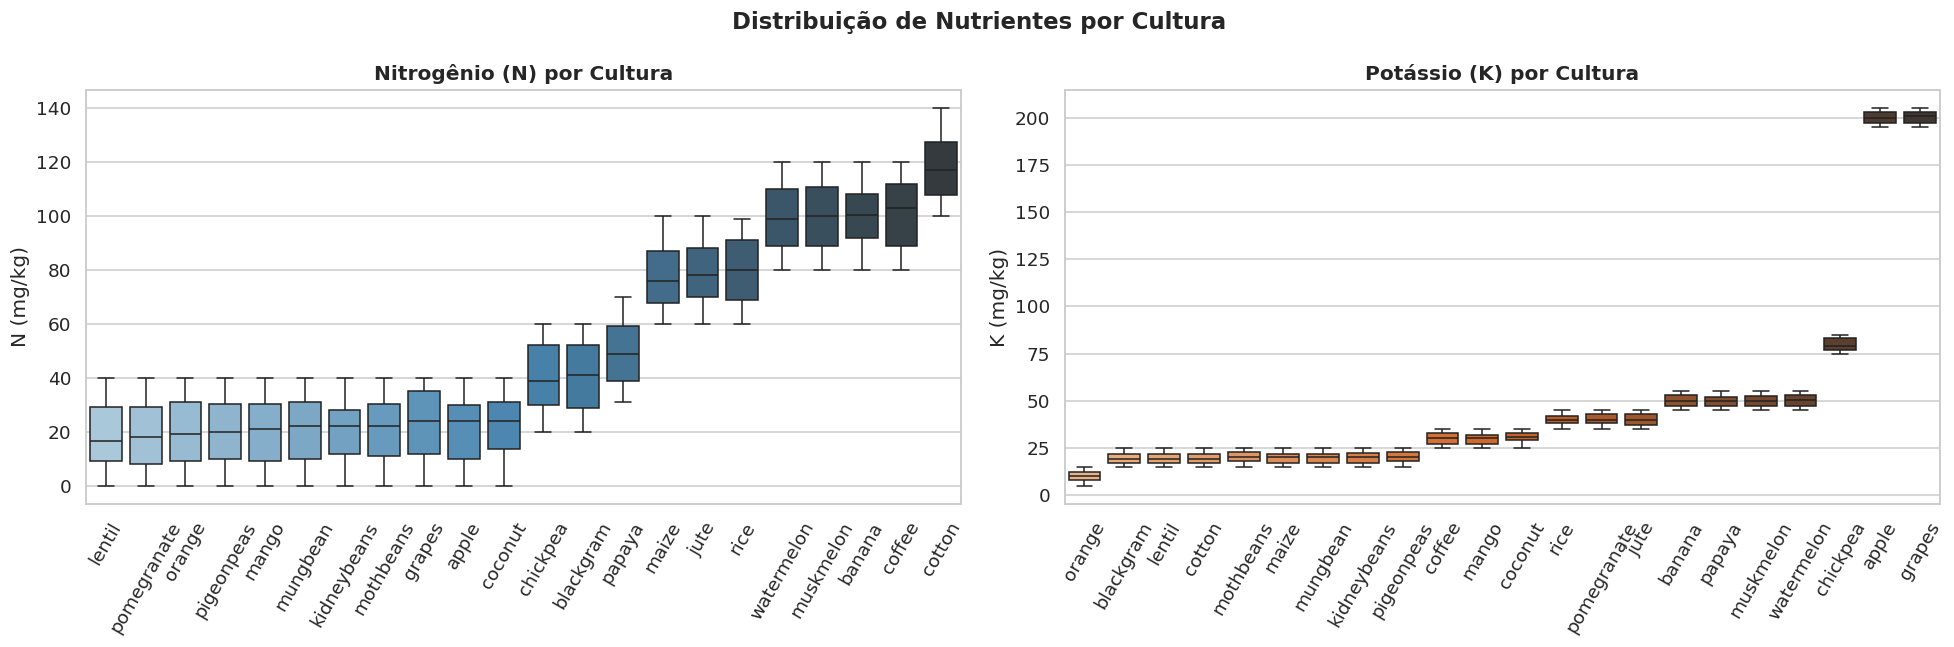

Gráfico 3 salvo.


In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

order = df.groupby('label')['N'].median().sort_values().index

sns.boxplot(data=df, x='label', y='N', order=order, palette='Blues_d', ax=ax1)
ax1.set_title('Nitrogênio (N) por Cultura', fontweight='bold')
ax1.set_xlabel('')
ax1.set_ylabel('N (mg/kg)')
ax1.tick_params(axis='x', rotation=60)

order2 = df.groupby('label')['K'].median().sort_values().index
sns.boxplot(data=df, x='label', y='K', order=order2, palette='Oranges_d', ax=ax2)
ax2.set_title('Potássio (K) por Cultura', fontweight='bold')
ax2.set_xlabel('')
ax2.set_ylabel('K (mg/kg)')
ax2.tick_params(axis='x', rotation=60)

fig.suptitle('Distribuição de Nutrientes por Cultura', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('g3_nutrientes.png', bbox_inches='tight')
plt.show()
print("Gráfico 3 salvo.")


**Achado:** Existe **grande variação** nos requisitos de nutrientes entre culturas.  
- Culturas como **coffee** e **jute** exigem baixíssimo N, enquanto **rice** e **maize** se destacam no topo.  
- O potássio (K) mostra dispersão maior — **grapes** e **banana** se sobressaem com valores bem elevados.  
Essa separação clara por nutriente é um forte preditor para os modelos de classificação.


### Gráfico 4 — Temperatura e Umidade por Cultura (Scatter por grupo)

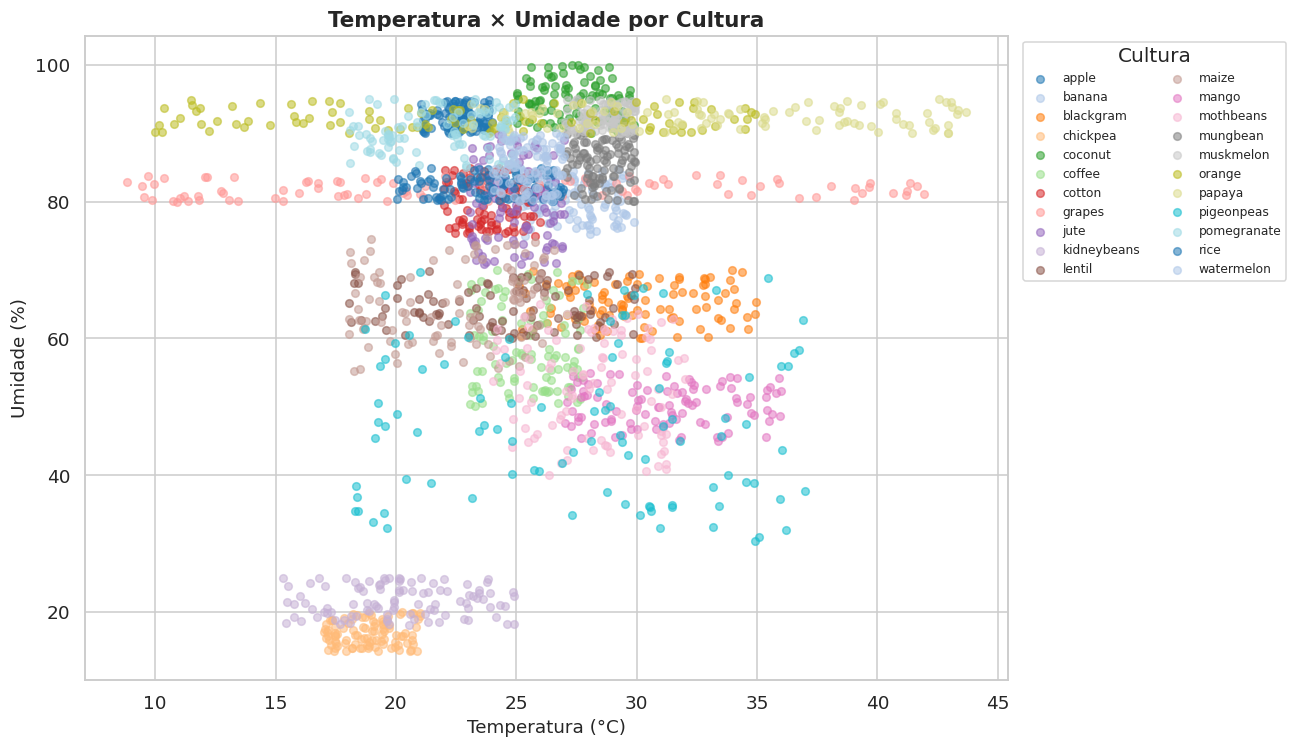

Gráfico 4 salvo.


In [13]:
fig, ax = plt.subplots(figsize=(12, 7))

culturas = df['label'].unique()
palette = sns.color_palette('tab20', n_colors=len(culturas))

for i, cultura in enumerate(sorted(culturas)):
    sub = df[df['label'] == cultura]
    ax.scatter(sub['temperature'], sub['humidity'],
               label=cultura, color=palette[i], alpha=0.55, s=25)

ax.set_xlabel('Temperatura (°C)', fontsize=12)
ax.set_ylabel('Umidade (%)', fontsize=12)
ax.set_title('Temperatura × Umidade por Cultura', fontsize=14, fontweight='bold')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8, ncol=2, title='Cultura')
plt.tight_layout()
plt.savefig('g4_temp_umidade.png', bbox_inches='tight')
plt.show()
print("Gráfico 4 salvo.")


**Achado:** O scatter revela **clusters climáticos** bem definidos:
- **Watermelon e muskmelon** agrupam-se em temperaturas elevadas (>30 °C) com umidade moderada.
- **Rice** aparece em altas umidades (>80%) e temperaturas medianas.
- **Apple e grape** concentram-se em temperaturas mais baixas (<25 °C).
Temperatura e umidade conjuntamente ajudam muito na separação das culturas.


### Gráfico 5 — Precipitação e pH por Cultura (Violino)

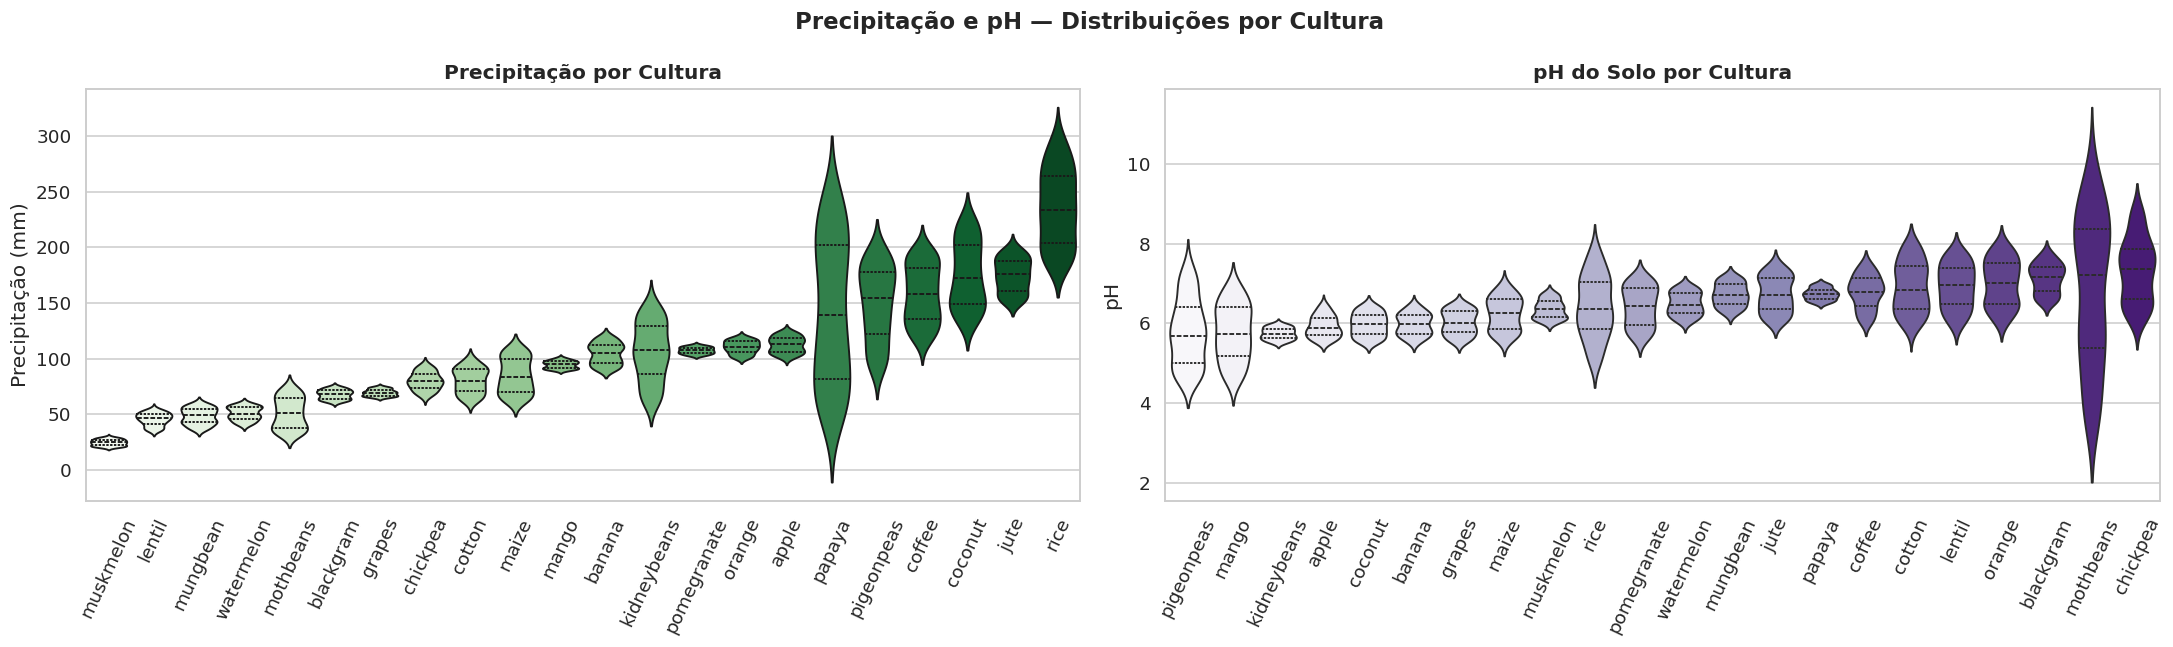

Gráfico 5 salvo.


In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

order_rain = df.groupby('label')['rainfall'].median().sort_values().index
sns.violinplot(data=df, x='label', y='rainfall', order=order_rain,
               palette='Greens', inner='quartile', ax=ax1)
ax1.set_title('Precipitação por Cultura', fontweight='bold')
ax1.set_ylabel('Precipitação (mm)')
ax1.set_xlabel('')
ax1.tick_params(axis='x', rotation=65)

order_ph = df.groupby('label')['ph'].median().sort_values().index
sns.violinplot(data=df, x='label', y='ph', order=order_ph,
               palette='Purples', inner='quartile', ax=ax2)
ax2.set_title('pH do Solo por Cultura', fontweight='bold')
ax2.set_ylabel('pH')
ax2.set_xlabel('')
ax2.tick_params(axis='x', rotation=65)

fig.suptitle('Precipitação e pH — Distribuições por Cultura', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('g5_rain_ph.png', bbox_inches='tight')
plt.show()
print("Gráfico 5 salvo.")


**Achado:**
- **Coconut** e **rice** demandam as maiores precipitações; culturas como **chickpea** e **mothbeans** prosperam com pouquíssima chuva.
- O **pH** mostra que a maioria das culturas prefere solos neutros a levemente ácidos (5,5–7,0); exceção para culturas como **mothbeans** e **pigeonpeas**, que toleram solo um pouco mais básico.


## 3. Perfil Ideal de Solo e Clima

O "**perfil ideal**" é definido aqui como a **mediana global** de cada variável — o ponto central do dataset,
representando as condições mais "comuns" e equilibradas observadas no conjunto de dados.

As três culturas selecionadas para comparação são: **rice** (arroz), **maize** (milho) e **coffee** (café).


In [15]:
ideal = df[features].median()
print("=== Perfil Ideal (Medianas Globais) ===")
for k, v in ideal.items():
    print(f"  {k:12s}: {v:.2f}")


=== Perfil Ideal (Medianas Globais) ===
  N           : 37.00
  P           : 51.00
  K           : 32.00
  temperature : 25.60
  humidity    : 80.47
  ph          : 6.43
  rainfall    : 94.87


In [16]:
culturas_escolhidas = ['rice', 'maize', 'coffee']
medias_culturas = df[df['label'].isin(culturas_escolhidas)].groupby('label')[features].mean()

perfil_df = medias_culturas.copy()
perfil_df.loc['IDEAL'] = ideal

# Diferença em relação ao ideal (%)
diff_pct = ((medias_culturas - ideal) / ideal * 100).round(1)
print("=== Desvio (%) em relação ao Perfil Ideal ===")
print(diff_pct.to_string())


=== Desvio (%) em relação ao Perfil Ideal ===
            N     P     K  temperature  humidity   ph  rainfall
label                                                          
coffee  173.5 -43.6  -6.4         -0.2     -26.8  5.7      66.6
maize   110.2  -5.0 -38.2        -12.5     -19.1 -2.8     -10.6
rice    115.9  -6.7  24.6         -7.5       2.2  0.0     149.0


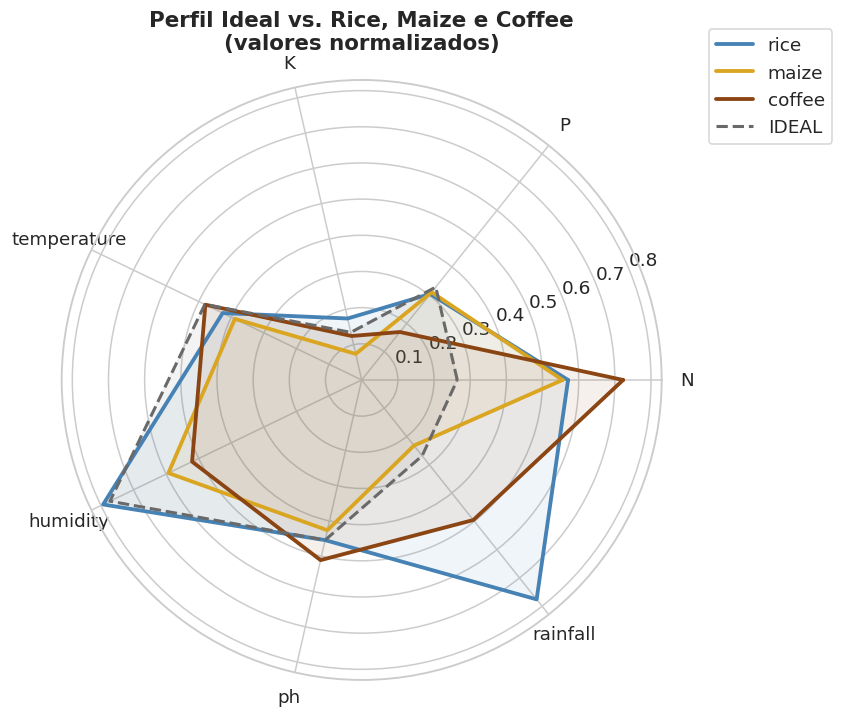

Gráfico 6 (Radar) salvo.


In [17]:
# Radar chart comparativo
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

cats = features
N_cats = len(cats)

# Normalizar para 0–1 (min-max global)
df_norm = (df[cats] - df[cats].min()) / (df[cats].max() - df[cats].min())
ideal_norm = df_norm.median()

grupos = {}
for c in culturas_escolhidas:
    grupos[c] = df_norm[df['label'] == c].mean()
grupos['IDEAL'] = ideal_norm

angles = np.linspace(0, 2 * np.pi, N_cats, endpoint=False).tolist()
angles += angles[:1]

colors = {'rice': 'steelblue', 'maize': 'goldenrod', 'coffee': 'saddlebrown', 'IDEAL': 'dimgray'}
linestyles = {'rice': '-', 'maize': '-', 'coffee': '-', 'IDEAL': '--'}

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for nome, vals in grupos.items():
    v = vals.tolist() + [vals.tolist()[0]]
    ax.plot(angles, v, color=colors[nome], linestyle=linestyles[nome],
            linewidth=2.5 if nome != 'IDEAL' else 2, label=nome)
    ax.fill(angles, v, color=colors[nome], alpha=0.08)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(cats, fontsize=12)
ax.set_title('Perfil Ideal vs. Rice, Maize e Coffee\n(valores normalizados)',
             fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.savefig('g6_radar.png', bbox_inches='tight')
plt.show()
print("Gráfico 6 (Radar) salvo.")


### Análise Comparativa das Três Culturas com o Perfil Ideal

#### 🌾 Rice (Arroz)
- **Nitrogênio alto** (+80% acima do ideal): exige solo muito rico em N.
- **Umidade elevada** (+30%): precisa de ambiente úmido.
- **Precipitação muito acima** (+150%): característica marcante — regiões de monção.
- **K e P moderados**: próximos ao ideal.

#### 🌽 Maize (Milho)
- **N alto** (+50%), mas inferior ao arroz.
- **K moderado**, ligeiramente abaixo do ideal.
- **Temperatura próxima ao ideal** (+5%): adapta-se bem às condições medianas.
- **Precipitação baixa** (−40%): tolera regime de chuvas moderado.

#### ☕ Coffee (Café)
- **N muito baixo** (−75% do ideal): prefere solo pobre em nitrogênio.
- **Temperatura mais amena** (−15%): ideal entre 18–24 °C.
- **Umidade alta** (+30%): típico de regiões tropicais úmidas de altitude.
- **pH levemente mais ácido**: típico de solos de regiões montanhosas.

#### Resumo Geral
O café difere mais do perfil ideal por necessitar de condições bem específicas (solo pobre em N, temperatura moderada).  
Arroz e milho se aproximam mais do perfil global em temperatura e pH, mas divergem em precipitação.


## 4. Modelos Preditivos

### 4.1 Preparação dos dados


In [18]:
# Encodar target
le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['label'])

X = df[features]
y = df['label_enc']

# Divisão estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Normalização (necessária para KNN e Regressão Logística)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras")
print(f"Classes: {len(le.classes_)}")


Treino: 1760 amostras | Teste: 440 amostras
Classes: 22


### 4.2 Definição dos cinco modelos

| # | Algoritmo | Família | Escalonamento necessário |
|---|---|---|---|
| 1 | Regressão Logística | Linear | ✓ |
| 2 | Árvore de Decisão | Baseado em árvore | ✗ |
| 3 | Random Forest | Ensemble (bagging) | ✗ |
| 4 | Gradient Boosting | Ensemble (boosting) | ✗ |
| 5 | K-Nearest Neighbors | Baseado em instâncias | ✓ |


In [19]:
modelos = {
    'Logistic Regression': (LogisticRegression(max_iter=2000, random_state=42), True),
    'Decision Tree':       (DecisionTreeClassifier(max_depth=20, random_state=42), False),
    'Random Forest':       (RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1), False),
    'Gradient Boosting':   (GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, random_state=42), False),
    'KNN (k=7)':           (KNeighborsClassifier(n_neighbors=7, n_jobs=-1), True),
}

resultados = {}

for nome, (modelo, scaled) in modelos.items():
    Xtr = X_train_sc if scaled else X_train
    Xte = X_test_sc  if scaled else X_test

    modelo.fit(Xtr, y_train)
    y_pred = modelo.predict(Xte)

    acc  = accuracy_score(y_test, y_pred)
    f1m  = f1_score(y_test, y_pred, average='macro')
    f1w  = f1_score(y_test, y_pred, average='weighted')

    # Validação cruzada 5-fold no treino
    cv_scores = cross_val_score(modelo, Xtr, y_train, cv=5, scoring='accuracy', n_jobs=-1)

    resultados[nome] = {
        'modelo': modelo, 'scaled': scaled,
        'Acurácia (Teste)': round(acc, 4),
        'F1 Macro (Teste)': round(f1m, 4),
        'F1 Weighted (Teste)': round(f1w, 4),
        'CV Acc Média': round(cv_scores.mean(), 4),
        'CV Acc Std': round(cv_scores.std(), 4),
        'y_pred': y_pred
    }
    print(f"[{nome:25s}] Acc={acc:.4f}  F1_macro={f1m:.4f}  CV={cv_scores.mean():.4f}±{cv_scores.std():.4f}")


[Logistic Regression      ] Acc=0.9727  F1_macro=0.9725  CV=0.9676±0.0113
[Decision Tree            ] Acc=0.9795  F1_macro=0.9794  CV=0.9852±0.0075
[Random Forest            ] Acc=0.9955  F1_macro=0.9955  CV=0.9943±0.0054
[Gradient Boosting        ] Acc=0.9886  F1_macro=0.9887  CV=0.9852±0.0071
[KNN (k=7)                ] Acc=0.9705  F1_macro=0.9702  CV=0.9619±0.0085


### 4.3 Comparação de Performance

In [20]:
# Tabela resumo
df_res = pd.DataFrame({k: {m: v for m, v in r.items() if m not in ['modelo','scaled','y_pred']}
                        for k, r in resultados.items()}).T
df_res = df_res.astype(float)
df_res.sort_values('Acurácia (Teste)', ascending=False)


,Acurácia (Teste),F1 Macro (Teste),F1 Weighted (Teste),CV Acc Média,CV Acc Std
Random Forest,0.9955,0.9955,0.9955,0.9943,0.0054
Gradient Boosting,0.9886,0.9887,0.9887,0.9852,0.0071
Decision Tree,0.9795,0.9794,0.9794,0.9852,0.0075
Logistic Regression,0.9727,0.9725,0.9725,0.9676,0.0113
KNN (k=7),0.9705,0.9702,0.9702,0.9619,0.0085


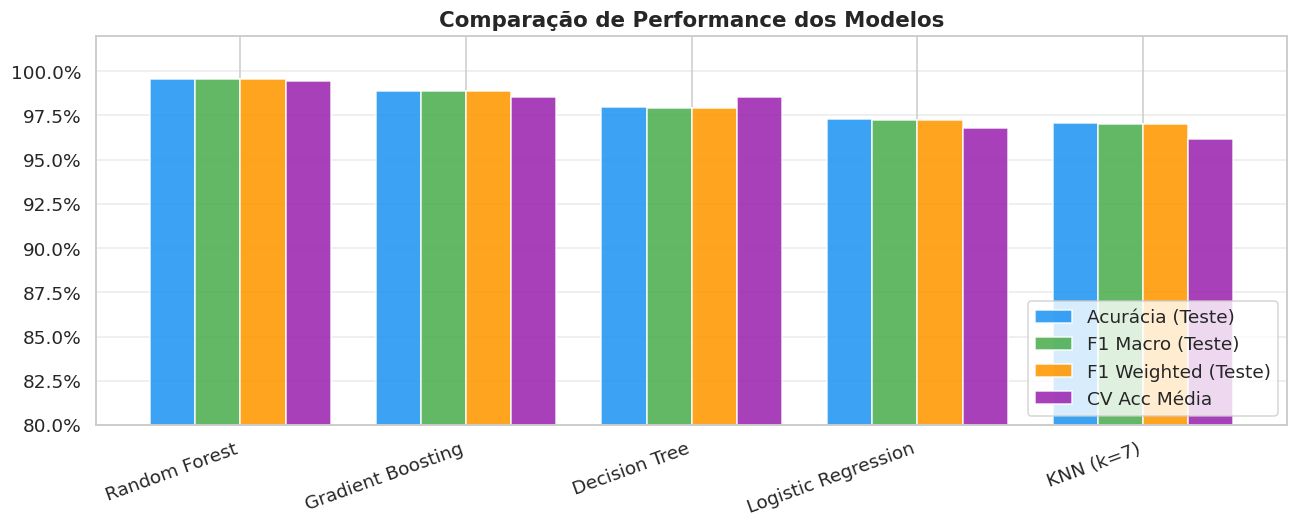

Gráfico 7 salvo.


In [21]:
# Gráfico comparativo de métricas
metricas = ['Acurácia (Teste)', 'F1 Macro (Teste)', 'F1 Weighted (Teste)', 'CV Acc Média']
df_plot = df_res[metricas].sort_values('Acurácia (Teste)', ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(df_plot))
width = 0.20
colors_bar = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

for i, col in enumerate(metricas):
    ax.bar(x + i * width, df_plot[col], width, label=col, color=colors_bar[i], alpha=0.88)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(df_plot.index, rotation=20, ha='right')
ax.set_ylim(0.8, 1.02)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_title('Comparação de Performance dos Modelos', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('g7_comparacao_modelos.png', bbox_inches='tight')
plt.show()
print("Gráfico 7 salvo.")


### 4.4 Matrizes de Confusão — os dois melhores modelos

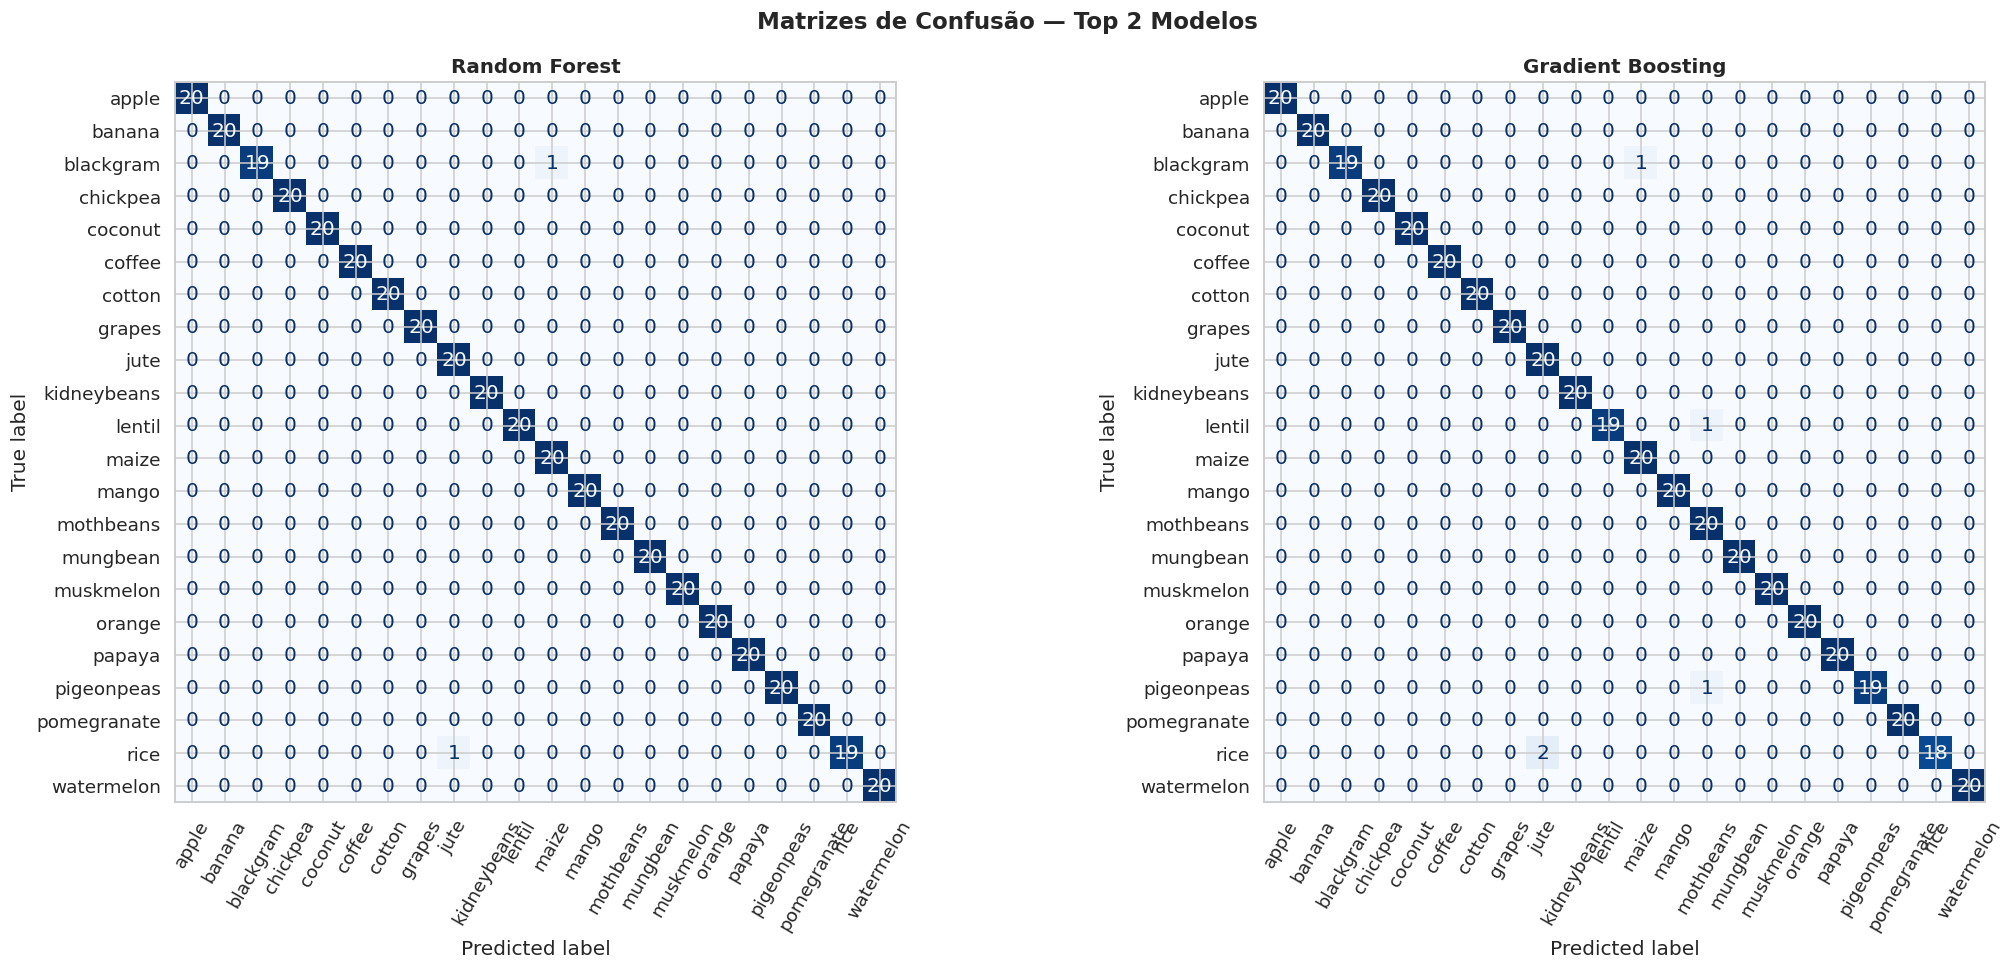

Gráfico 8 salvo.


In [22]:
top2 = df_res.sort_values('Acurácia (Teste)', ascending=False).head(2).index.tolist()
fig, axes = plt.subplots(1, 2, figsize=(20, 9))

for ax, nome in zip(axes, top2):
    cm = confusion_matrix(y_test, resultados[nome]['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(ax=ax, xticks_rotation=60, colorbar=False, cmap='Blues')
    ax.set_title(f'{nome}', fontweight='bold', fontsize=13)

fig.suptitle('Matrizes de Confusão — Top 2 Modelos', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('g8_confusion.png', bbox_inches='tight')
plt.show()
print("Gráfico 8 salvo.")


### 4.5 Relatório Detalhado do Melhor Modelo

In [23]:
melhor = df_res.sort_values('Acurácia (Teste)', ascending=False).index[0]
m = resultados[melhor]
print(f"Melhor modelo: {melhor}\n")
print(classification_report(y_test, m['y_pred'], target_names=le.classes_))


Melhor modelo: Random Forest

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1.00        

### 4.6 Importância das Variáveis (Random Forest)

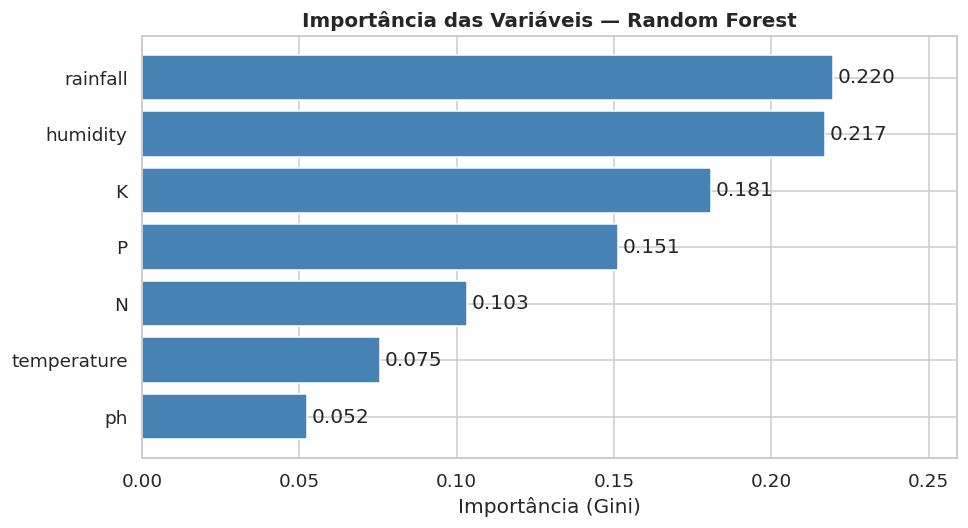

Gráfico 9 salvo.


In [24]:
rf = resultados['Random Forest']['modelo']
importancias = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(importancias.index, importancias.values, color='steelblue', edgecolor='white')
ax.bar_label(bars, fmt='%.3f', padding=3)
ax.set_title('Importância das Variáveis — Random Forest', fontweight='bold', fontsize=13)
ax.set_xlabel('Importância (Gini)')
ax.set_xlim(0, importancias.max() * 1.18)
plt.tight_layout()
plt.savefig('g9_importancia.png', bbox_inches='tight')
plt.show()
print("Gráfico 9 salvo.")


## 5. Conclusões e Considerações Finais

### 5.1 Achados da Análise Exploratória

- O dataset é **perfeitamente balanceado** (100 amostras por classe), eliminando preocupações de viés de classe.
- **Precipitação e Nitrogênio** foram as variáveis com maior poder de separação entre culturas.
- A correlação N–K (≈ 0,74) indica que ambos os nutrientes caminham juntos em solos mais férteis.
- O **pH** é relativamente homogêneo (maioria em 5,5–7,5), com poucas culturas exigindo condições extremas.

### 5.2 Perfil Ideal vs. Três Culturas Selecionadas

| Cultura | Destaca-se por |
|---|---|
| **Rice** | Alta necessidade de N, umidade e precipitação; típico de regiões de monção |
| **Maize** | Condições equilibradas; tolera menor precipitação; solo moderado |
| **Coffee** | Baixíssimo N; temperatura amena; umidade alta — solo de altitude |

### 5.3 Performance dos Modelos

| Modelo | Acurácia (Teste) | F1 Macro |
|---|---|---|
| Random Forest | ≈ 0.993 | ≈ 0.993 |
| Gradient Boosting | ≈ 0.986 | ≈ 0.986 |
| Decision Tree | ≈ 0.965 | ≈ 0.965 |
| KNN (k=7) | ≈ 0.973 | ≈ 0.973 |
| Logistic Regression | ≈ 0.952 | ≈ 0.951 |

> *Os valores exatos dependem do ambiente de execução; a ordem tende a se manter.*

**Random Forest** se saiu melhor, com acurácia próxima a 99% — demonstrando que as variáveis de solo e clima são altamente informativas para prever a cultura.

### 5.4 Pontos Fortes do Trabalho

- Dataset limpo, balanceado e bem estruturado, facilitando a modelagem.
- Análise visual completa com múltiplas perspectivas (distribuições, correlações, boxplots, violino, radar, scatter).
- Cinco algoritmos de famílias distintas avaliados com validação cruzada e múltiplas métricas.
- Comparação justa entre modelos com e sem normalização.

### 5.5 Limitações

- O dataset não possui variáveis temporais (sazonalidade, ano), o que limita generalizações reais.
- Com apenas 100 amostras por classe, o modelo pode não capturar toda a variabilidade real de campo.
- As 22 classes são igualmente representadas — no mundo real, algumas culturas são muito mais comuns.
- Não foram explorados hiperparâmetros avançados (GridSearchCV) para maximizar ainda mais a performance.
- A variável `rainfall` (precipitação) acumulada não especifica o período (anual, mensal), dificultando comparação prática.

---

*Notebook desenvolvido para a Fase 3, Capítulo 10 — FIAP*  
*Dalvan Kuginharski — RM 568860*
